# German Electricity Demand Forecasting

## Part 2: Stationarity Analysis

This notebook investigates the stationarity properties of the weekly German electricity demand series using visualisation, seasonal decomposition, statistical tests and differencing techniques.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

import warnings
warnings.filterwarnings("ignore")

In [16]:
weekly_load = pd.read_csv(
    "https://raw.githubusercontent.com/dekshinaudayan/german-electricity-demand-forecasting/refs/heads/main/data/processed/weekly_load.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

## Weekly Electricity Demand Series

Load the aggregated weekly electricity demand series for stationarity assessment and model preparation.

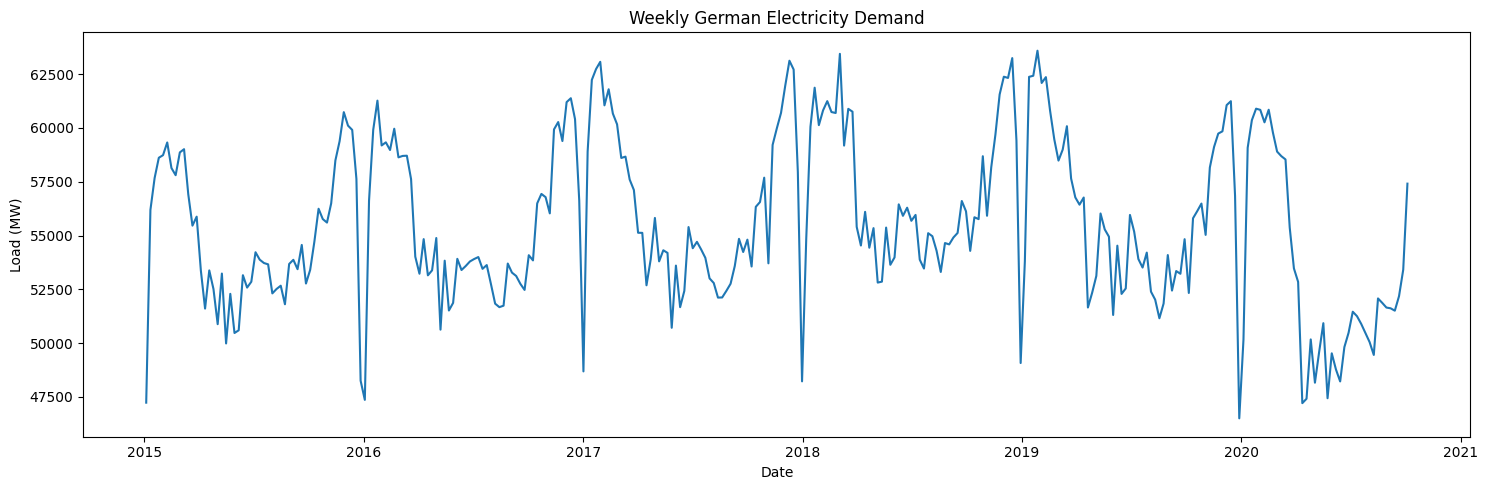

In [17]:
plt.figure(figsize=(15,5))

plt.plot(
    weekly_load.index,
    weekly_load["load"]
)

plt.title(
    "Weekly German Electricity Demand"
)

plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.tight_layout()

plt.savefig(
    "weekly_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

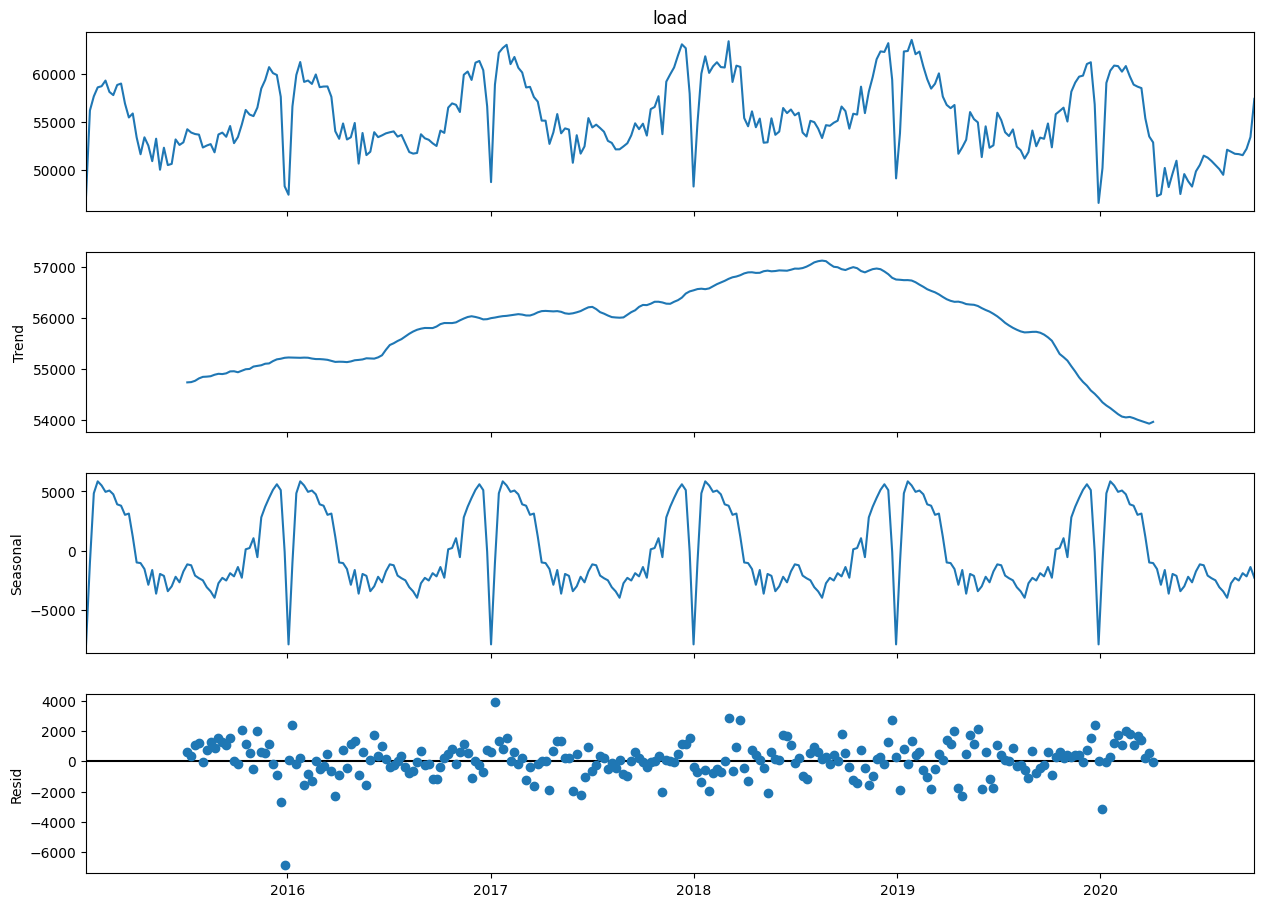

In [18]:
decomposition = seasonal_decompose(
    weekly_load["load"],
    model="additive",
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(14,10)

plt.savefig(
    "seasonal_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Seasonal Decomposition

The weekly electricity demand series is decomposed into trend, seasonal and residual components to identify underlying temporal structure.

## Augmented Dickey-Fuller (ADF) Test

The ADF test is used to determine whether the weekly electricity demand series contains a unit root. The null hypothesis is that the series is non-stationary.

In [19]:
adf_result = adfuller(
    weekly_load["load"]
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: -4.047471855678481
p-value: 0.0011813497340154584
Critical Value (1%): -3.4529449243622383
Critical Value (5%): -2.871489553425686
Critical Value (10%): -2.572071437887033


## KPSS Test

The KPSS test is used as a complementary stationarity test. The null hypothesis is that the series is stationary.

In [20]:
kpss_result = kpss(
    weekly_load["load"],
    regression="c"
)

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

for key, value in kpss_result[3].items():
    print(f"Critical Value ({key}): {value}")

KPSS Statistic: 0.16037407809773105
p-value: 0.1
Critical Value (10%): 0.347
Critical Value (5%): 0.463
Critical Value (2.5%): 0.574
Critical Value (1%): 0.739


## Autocorrelation Analysis

Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are used to identify potential autoregressive and moving-average structures in the weekly electricity demand series.

<Figure size 1200x500 with 0 Axes>

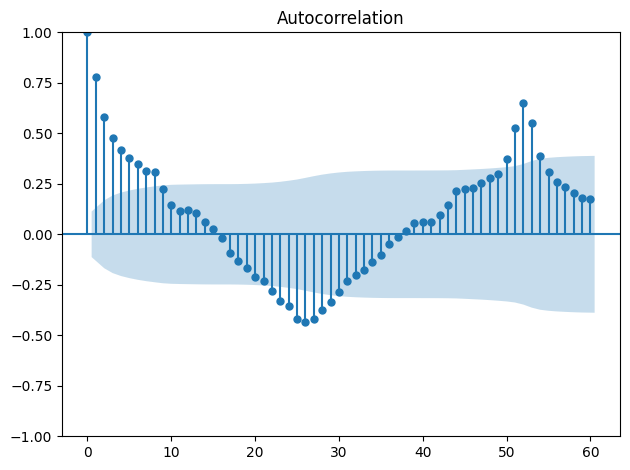

In [21]:
plt.figure(figsize=(12,5))

plot_acf(
    weekly_load["load"],
    lags=60
)

plt.tight_layout()

plt.savefig(
    "acf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1200x500 with 0 Axes>

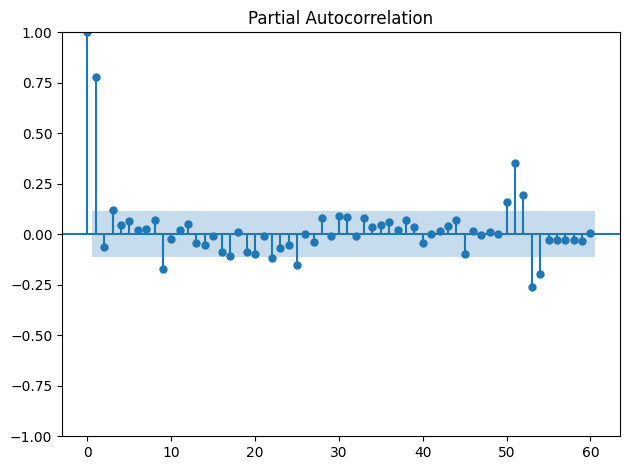

In [22]:
plt.figure(figsize=(12,5))

plot_pacf(
    weekly_load["load"],
    lags=60,
    method="ywm"
)

plt.tight_layout()

plt.savefig(
    "pacf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## First Differencing

First differencing is applied to investigate whether any remaining trend component can be removed and to prepare the series for autoregressive modelling if required.

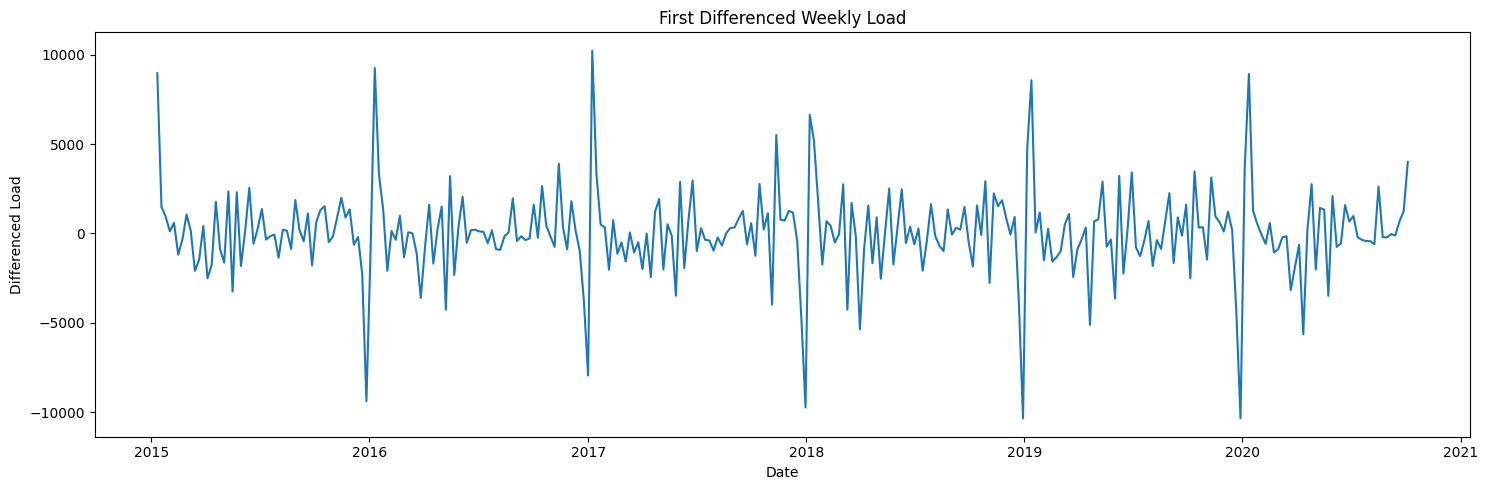

In [23]:
weekly_diff = weekly_load["load"].diff()

plt.figure(figsize=(15,5))

plt.plot(
    weekly_diff
)

plt.title(
    "First Differenced Weekly Load"
)

plt.xlabel("Date")
plt.ylabel("Differenced Load")

plt.tight_layout()

plt.savefig(
    "first_difference.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Seasonal Differencing

A seasonal difference with period 52 weeks is applied to remove annual seasonality and prepare the series for seasonal autoregressive modelling.

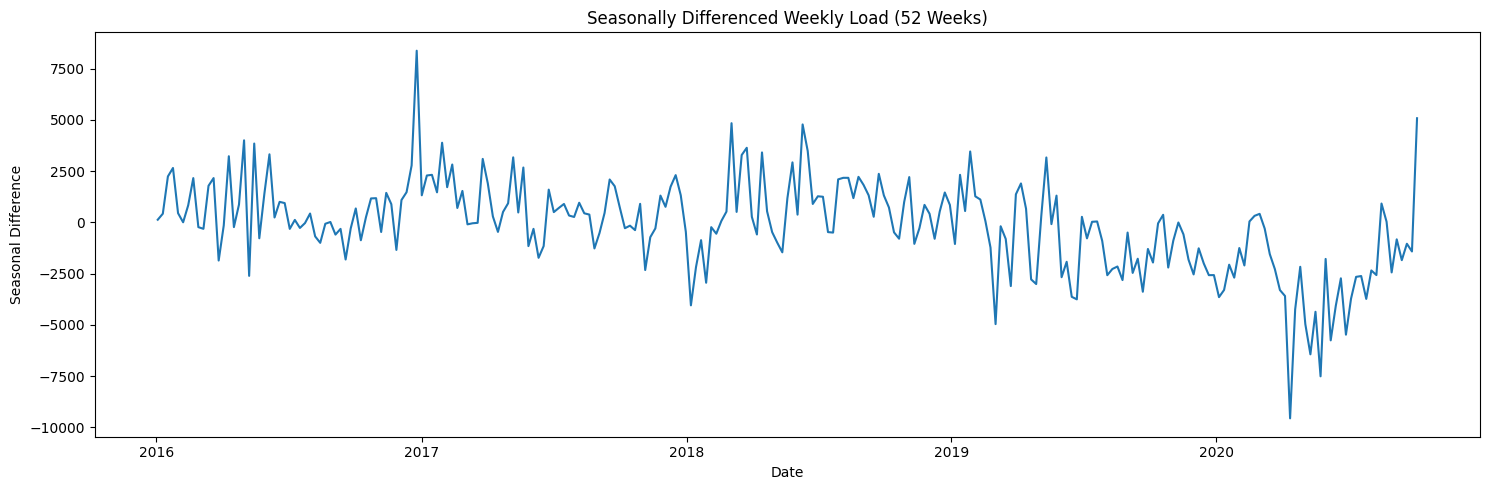

In [24]:
seasonal_diff = weekly_load["load"].diff(52)


# Plot seasonally differenced series

plt.figure(figsize=(15,5))

plt.plot(
    seasonal_diff
)

plt.title(
    "Seasonally Differenced Weekly Load (52 Weeks)"
)

plt.xlabel("Date")
plt.ylabel("Seasonal Difference")

plt.tight_layout()

plt.savefig(
    "seasonal_difference.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Remove missing values created by differencing

seasonal_diff_clean = seasonal_diff.dropna()

# Apply ADF test to check stationarity

adf_seasonal = adfuller(
    seasonal_diff_clean
)

print("ADF Statistic:", adf_seasonal[0])
print("p-value:", adf_seasonal[1])

ADF Statistic: -4.295072288761103
p-value: 0.00045302191052539235


## Stationarity Conclusion

The weekly electricity demand series exhibits strong annual seasonality and a slowly varying trend component. Seasonal decomposition confirms the presence of recurring yearly patterns.

The ADF test rejects the null hypothesis of a unit root, while the KPSS test fails to reject the null hypothesis of stationarity. The ACF and PACF plots indicate strong short-term persistence and clear annual seasonal structure around lag 52.

First differencing removes most of the trend, while seasonal differencing removes the annual seasonal pattern. These results support the use of seasonal autoregressive models such as SARIMA and SARIMAX.